🧠 Explainability analysis Jupyter notebook

📦 Install required packages

In [2]:
!pip install nltk sentence-transformers torch PyMuPDF
!pip install pandas
!pip install matplotlib
!pip install -U kaleido
!pip install plotly

  Using cached nltk-3.9.1-py3-none-any.whl.metadata (2.9 kB)
  Using cached sentence_transformers-4.1.0-py3-none-any.whl.metadata (13 kB)
  Using cached torch-2.7.0-cp313-cp313-manylinux_2_28_x86_64.whl.metadata (29 kB)
  Using cached pymupdf-1.25.5-cp39-abi3-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (3.4 kB)
  Using cached click-8.2.0-py3-none-any.whl.metadata (2.5 kB)
  Using cached joblib-1.5.0-py3-none-any.whl.metadata (5.6 kB)
  Using cached regex-2024.11.6-cp313-cp313-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (40 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached transformers-4.51.3-py3-none-any.whl.metadata (38 kB)
  Using cached scikit_learn-1.6.1-cp313-cp313-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (18 kB)
  Using cached scipy-1.15.3-cp313-cp313-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached pillow-11.2.1-cp313-cp313-manylinux_2_28_x86_64.whl.metadata (8.9 kB)
  Using cached

📚 Import libraries

In [3]:
import nltk
import torch
import fitz  # PyMuPDF
import pandas as pd
from pathlib import Path
from sentence_transformers import SentenceTransformer, util
from nltk.tokenize import sent_tokenize
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio

nltk.download('punkt')
nltk.download('punkt_tab')


/home/bogdan/Desktop/Execo-rep-pkg/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package punkt to /home/bogdan/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/bogdan/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

🏷️ Define explainability codebook

In [33]:
codebook = [
    {"code": "Transparency", "description": "The degree to which a model internal mechanics can be understood."},
    {"code": "Interpretability", "description": "The extent to which users can comprehend and predict the model output."},
    {"code": "Fidelity", "description": "How well an explanation reflects the true decision-making process of the model."},
    {"code": "Simulatability", "description": "Whether a human can replicate the decision-making process."},
    {"code": "Actionability", "description": "The practical utility of an explanation in refining or debugging model performance."},
    {"code": "Robustness", "description": "The consistency and reliability of explanations under different conditions."}
]
code_descriptions = [code['description'] for code in codebook]

📄 Load and extract text from all PDFs in the folder

In [34]:
def extract_text_from_pdf(pdf_path):
    text = ""
    with fitz.open(pdf_path) as doc:
        for page in doc:
            text += page.get_text() + ""
    return text

# Set path to your folder of PDFs
pdf_folder = Path("./Papers/")  # Put your PDFs here
pdf_files = list(pdf_folder.glob("*.pdf"))
print(f"Found {len(pdf_files)} PDF files.")

Found 24 PDF files.


🤖 Load model

In [35]:
model = SentenceTransformer('all-mpnet-base-v2')

🧠 Process each PDF

In [36]:
results = []
threshold = 0.5

code_embeddings = model.encode(code_descriptions, convert_to_tensor=True)

for pdf_path in pdf_files:
    text = extract_text_from_pdf(pdf_path)
    segments = sent_tokenize(text)
    text_embeddings = model.encode(segments, convert_to_tensor=True)
    
    for i, segment in enumerate(segments):
        sim_scores = util.cos_sim(text_embeddings[i], code_embeddings)[0]
        for score, code_idx in zip(sim_scores, range(len(codebook))):
            if score >= threshold:
                results.append({
                    "File": pdf_path.name,
                    "Text Segment": segment,
                    "Code": codebook[code_idx]['code'],
                    "Score": float(score)
                })

print(f"✅ Done processing {len(pdf_files)} files. Total coded segments: {len(results)}")

✅ Done processing 24 files. Total coded segments: 2342


💾 Export to CSV

In [37]:
df = pd.DataFrame(results)
df.to_csv("./CSVs/coded_output_from_pdfs_explainability.csv", index=False, encoding='utf-8')
df.head()

,File,Text Segment,Code,Score
0,2306.05685v4.pdf,"Consequently, this suggests LLM-as-a-judge is ...",Simulatability,0.513048
1,2306.05685v4.pdf,"Additionally, LLM judges provide\nnot only sco...",Fidelity,0.527954
2,2306.05685v4.pdf,We examine this effect statistically.,Robustness,0.505422
3,2306.05685v4.pdf,"Compared to humans, we do observe that some ju...",Simulatability,0.520170
4,2306.05685v4.pdf,We also\nshow that GPT-4’s judgments may help ...,Simulatability,0.508421


💾 Aggregate frequency and document count per code

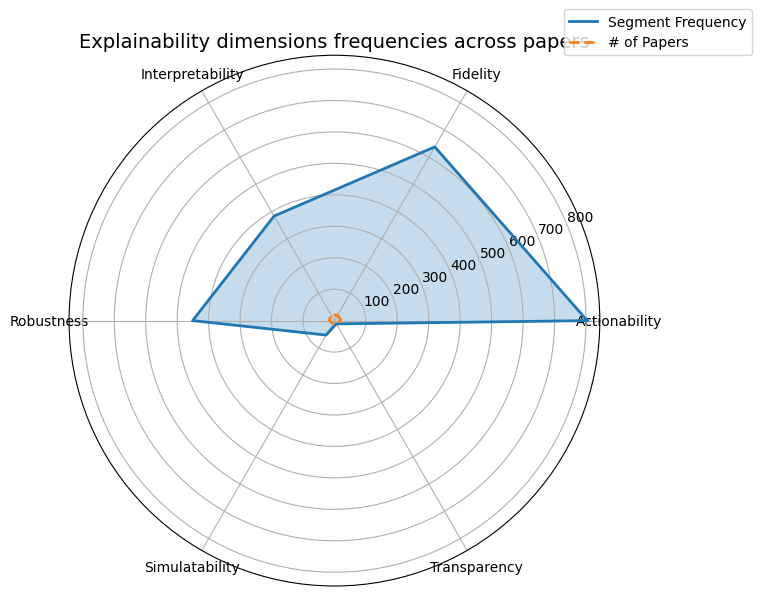

In [38]:
code_stats = df.groupby("Code").agg({
    "Text Segment": "count",
    "File": pd.Series.nunique
}).rename(columns={
    "Text Segment": "Frequency",
    "File": "Documents"
}).reset_index()

labels = code_stats["Code"].tolist()
freq = code_stats["Frequency"].tolist()
docs = code_stats["Documents"].tolist()
# Radar setup
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
freq += freq[:1]
docs += docs[:1]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 6), subplot_kw=dict(polar=True))
ax.plot(angles, freq, label="Segment Frequency", linewidth=2)
ax.fill(angles, freq, alpha=0.25)

ax.plot(angles, docs, label="# of Papers", linestyle='dashed', linewidth=2)
ax.fill(angles, docs, alpha=0.1)

ax.set_thetagrids(np.degrees(angles[:-1]), labels)
plt.title("Explainability dimensions frequencies across papers", fontsize=14)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()

# Show plot
plt.show()

Radar plot with the curated CSV file through ChatGPT

In [4]:
# Load data
data = pd.read_csv("./CSVs/curated_codes_explainability.csv")
label_counts = data['Code'].value_counts()

# Create bar plot (occurrences of codes)
fig = go.Figure(data=go.Bar(
    x=label_counts.index,
    y=label_counts.values,
    marker_color='blue'
))

fig.update_layout(
    xaxis_title='Codes',
    yaxis_title='Number of Occurrences',
    showlegend=False
)

# Export as PDF
pio.write_image(fig, "./Figures/bar_plot_codes_occurrences_explainability.pdf", format="pdf")

In [5]:
# Load data
data = pd.read_csv("./CSVs/curated_codes_explainability.csv")

# Count the number of unique papers per code
papers_per_code = data.groupby('Code')['File'].nunique().sort_values(ascending=False)

# Create bar plot (number of papers per code)
fig = go.Figure(data=go.Bar(
    x=papers_per_code.index,
    y=papers_per_code.values,
    marker_color='blue'
))

fig.update_layout(
    xaxis_title='Code',
    yaxis_title='Number of Papers',
    xaxis_tickangle=-45,
    showlegend=False
)

# Export as PDF
pio.write_image(fig, "./Figures/bar_plot_papers_per_code_explainability.pdf", format="pdf")